In [3]:
library("SeuratDisk")
library("zellkonverter")
library("Seurat")
library(tidyverse)
library(ComplexHeatmap)

Lade n"otiges Paket: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [11]:
expression_file <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/normalized_exp_df.csv"
expression <- read.csv(expression_file)

In [23]:
expression_arc <- expression %>%
    select(!c(patient_ID,X)) %>%
    mutate(across(where(is.numeric), ~ asinh(.x / 5)))

In [27]:
expression_agg <- expression_arc %>%
    group_by(cell_type) %>%
    summarise(across(where(is.numeric), mean)) %>%
    column_to_rownames(var = "cell_type") %>%
    scale()
expression_agg


,ACTIN,ARGINASE1,BCL2,BETACATENIN,CD3,CD4,CD8A,CD11B,CD11C,CD15,...,P53,PCNA,PODOPLANIN,PRAME,PSANCAM,S100,TIM3,TIM3.1,VIMENTIN,VISTA
Actin+_cells,3.1320064,-0.38561267,-1.12179547,-1.470105657,-0.89752798,-1.83307715,-1.16575486,-1.3406414,-1.158891253,-0.55698625,...,-1.83892995,-1.5676773,-0.74797583,-0.53473769,-0.6340105,-0.95910299,-1.84615623,-1.2543765,0.5151095,-0.8473678
B_cells,0.4245171,-0.59882022,2.34463523,0.778993386,0.41066066,-0.36538629,-0.07000759,-0.4312401,0.242967257,-0.46188163,...,-0.26893140,-0.7174058,0.44107388,-1.85836987,2.2876404,-0.24532987,0.43379905,0.5563841,-1.0842004,-0.4917120
CD4+_T_cells,1.0055273,-0.42394794,1.55995517,0.393572758,2.19285511,1.87779140,0.20886778,-0.4721704,0.019523382,-0.33297542,...,-0.37925678,-0.6243341,-0.11091033,-0.61987069,0.4296530,-0.28724999,-0.15180043,0.1866132,-0.3356705,0.2727409
CD8+_T_cells,0.6821458,-0.29343929,1.92143960,0.920355682,2.18553828,0.42081607,2.93994644,-0.2340834,0.307057944,-0.15087425,...,0.94482024,0.2775565,-0.17596360,-0.09391200,0.9910421,0.02230551,0.46273880,0.5034837,-0.4407752,0.7679656
DCs,-0.1738713,-0.12728839,-0.18447464,0.598132424,-0.40861316,0.29526959,-0.03631982,0.3847440,2.415798095,0.13571845,...,-0.03875727,-0.2321998,-0.27197431,-0.45930214,0.1576328,0.11188449,0.96905896,0.4021886,0.1833859,0.2982978
Endothelial_cells,0.5782687,-0.40711185,-0.24606955,-0.795507161,-0.94682236,-0.84479361,-1.23103274,-0.6029108,-0.570666299,-0.53380177,...,-0.60899540,-0.7211203,-0.67845188,0.15521811,-0.1281045,-0.71893744,-0.18122704,-1.3411679,1.3100526,0.1019028
Epithelial_cells,-1.4677098,-0.37405324,-0.46267592,1.974506179,-0.45371052,-0.53122542,-0.45136495,-0.4285281,0.971163843,-0.63042838,...,0.53831692,-0.7812314,-0.16868015,1.47636519,-0.6860732,3.46510170,2.07628828,-0.4726741,-1.1040134,-1.7593934
Granulocytes,-0.7508654,2.46397352,-0.32892532,0.554753486,0.04426725,-0.01472353,1.03198937,3.1489724,-0.707636601,2.78906776,...,1.24750811,0.6560359,-0.31608045,0.35035264,-0.1797116,0.63636643,0.57362029,-0.8179367,-0.7770270,2.1610115
Lymphatic_endothelial_cells,-0.1053218,-0.44203213,-0.68222481,-0.844620397,-0.73002689,-0.54288497,-0.70159144,-0.5354244,-1.483924408,-0.53945246,...,-1.03737413,-0.3908514,3.88176949,0.41830541,-0.7531431,-0.55088258,-0.34139418,-0.6338005,0.1324705,-0.6672737
M1_M2_macrophages,-0.2207971,-0.07106358,0.15700050,0.517169600,0.15363925,1.41758724,0.29649290,0.8125658,1.034538383,-0.01848612,...,0.75792477,0.8554760,-0.05660298,-0.39886406,1.0184776,0.25040410,1.04822461,1.6815695,1.5727369,0.4513985


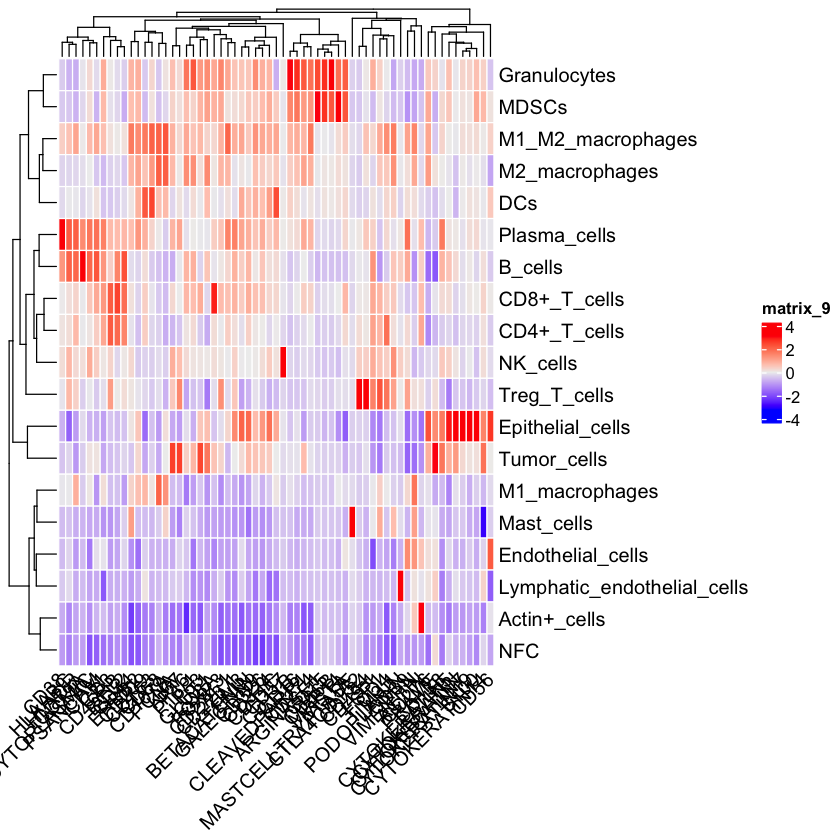

In [38]:
Heatmap(expression_agg,
        cluster_rows = TRUE,
        cluster_columns = TRUE,
        rect_gp = gpar(col = "white", lwd = 1),
        column_names_rot = 45
        )